In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    average_precision_score
)

from imblearn.over_sampling import SMOTE, SMOTENC

In [6]:
original_bank = pd.read_csv("/Users/Owner/Desktop/Bank-Project/Datasets/bank/bank-full.csv", sep=";")

X = original_bank.drop(columns=["y"])
y = original_bank["y"].map({"no": 0, "yes": 1})

categorical_cols = X.select_dtypes(include=["object", "string"]).columns.tolist()
numeric_cols = X.select_dtypes(exclude=["object", "string"]).columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Categorical columns:", categorical_cols)
print("Numeric columns:", numeric_cols)

print("\nOriginal train class balance:")
print(y_train.value_counts())

models = {
    "Logistic Regression": LogisticRegression(max_iter=2000, random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "XGBoost": XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    )
}

Train shape: (36168, 16)
Test shape: (9043, 16)
Categorical columns: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']
Numeric columns: ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']

Original train class balance:
y
0    31937
1     4231
Name: count, dtype: int64


In [7]:
#Preprocessing helpers
def prepare_prepro(X_train_raw, X_test_raw, categorical_cols, numeric_cols):
    
    X_train_cat = pd.get_dummies(X_train_raw[categorical_cols], drop_first=False)
    X_test_cat = pd.get_dummies(X_test_raw[categorical_cols], drop_first=False)

    X_train_cat, X_test_cat = X_train_cat.align(
        X_test_cat, join="left", axis=1, fill_value=0
    )

    scaler = StandardScaler()

    X_train_num = pd.DataFrame(
        scaler.fit_transform(X_train_raw[numeric_cols]),
        columns=numeric_cols,
        index=X_train_raw.index
    )

    X_test_num = pd.DataFrame(
        scaler.transform(X_test_raw[numeric_cols]),
        columns=numeric_cols,
        index=X_test_raw.index
    )

    X_train_final = pd.concat([X_train_num, X_train_cat], axis=1)
    X_test_final = pd.concat([X_test_num, X_test_cat], axis=1)

    return X_train_final, X_test_final

def evaluate_models(models, X_train_final, X_test_final, y_train, y_test, scenario_name):
    results = []
    outputs = {}

    for model_name, model in models.items():
        model.fit(X_train_final, y_train)
        y_pred = model.predict(X_test_final)

        if hasattr(model, "predict_proba"):
            y_prob = model.predict_proba(X_test_final)[:, 1]
            auc = roc_auc_score(y_test, y_prob)
        elif hasattr(model, "decision_function"):
            y_prob = model.decision_function(X_test_final)
            auc = roc_auc_score(y_test, y_prob)
        else:
            y_prob = None
            auc = np.nan

        results.append({
            "Scenario": scenario_name,
            "Model": model_name,
            "Accuracy": accuracy_score(y_test, y_pred),
            "Precision": precision_score(y_test, y_pred, zero_division=0),
            "Recall": recall_score(y_test, y_pred, zero_division=0),
            "F1-score": f1_score(y_test, y_pred, zero_division=0),
            "ROC-AUC": auc,
            "Confusion Matrix": confusion_matrix(y_test, y_pred)
        })

        outputs[model_name] = {
            "y_pred": y_pred,
            "y_prob": y_prob
        }

    return pd.DataFrame(results), outputs


In [8]:
X_train_base, X_test_base = prepare_prepro(
    X_train, X_test, categorical_cols, numeric_cols
)

baseline_results, baseline_outputs = evaluate_models(
    models=models,
    X_train_final=X_train_base,
    X_test_final=X_test_base,
    y_train=y_train,
    y_test=y_test,
    scenario_name="Baseline"
)

print(baseline_results[[
    "Scenario", "Model", "Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"
]].sort_values(by="F1-score", ascending=False))

   Scenario                Model  Accuracy  Precision    Recall  F1-score  \
2  Baseline              XGBoost  0.905452   0.626717  0.474480  0.540075   
1  Baseline        Random Forest  0.905452   0.661882  0.392250  0.492582   
0  Baseline  Logistic Regression  0.901250   0.644483  0.347826  0.451811   

    ROC-AUC  
2  0.928747  
1  0.925822  
0  0.905574  


In [9]:
#SMOTE
X_train_smote, X_test_smote = prepare_prepro(
    X_train, X_test, categorical_cols, numeric_cols
)

smote = SMOTE(random_state=42)
X_train_smote_res, y_train_smote_res = smote.fit_resample(X_train_smote, y_train)

print("\nAfter plain SMOTE:")
print(pd.Series(y_train_smote_res).value_counts())

smote_results, smote_outputs = evaluate_models(
    models=models,
    X_train_final=X_train_smote_res,
    X_test_final=X_test_smote,
    y_train=y_train_smote_res,
    y_test=y_test,
    scenario_name="SMOTE"
)

print(smote_results[[
    "Scenario", "Model", "Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"
]].sort_values(by="F1-score", ascending=False))


After plain SMOTE:
y
0    31937
1    31937
Name: count, dtype: int64
  Scenario                Model  Accuracy  Precision    Recall  F1-score  \
2    SMOTE              XGBoost  0.907774   0.605066  0.609641  0.607345   
1    SMOTE        Random Forest  0.898927   0.563943  0.600189  0.581502   
0    SMOTE  Logistic Regression  0.899591   0.573242  0.554820  0.563881   

    ROC-AUC  
2  0.930712  
1  0.926234  
0  0.894602  


In [ ]:
#SMOTENC 
smotenc = SMOTENC(
    categorical_features=categorical_cols,
    random_state=42,
    k_neighbors=5
)

X_train_smotenc_res, y_train_smotenc_res = smotenc.fit_resample(X_train, y_train)

print("\nAfter SMOTENC:")
print(pd.Series(y_train_smotenc_res).value_counts())
print(type(X_train_smotenc_res))
print(X_train_smotenc_res.shape)

if not isinstance(X_train_smotenc_res, pd.DataFrame):
    X_train_smotenc_res = pd.DataFrame(X_train_smotenc_res, columns=X_train.columns)

X_test_smotenc = X_test.copy()

print(type(X_train_smotenc_res))
print(type(X_test_smotenc))


After SMOTENC:
y
0    31937
1    31937
Name: count, dtype: int64
<class 'pandas.DataFrame'>
(63874, 16)
<class 'pandas.DataFrame'>
<class 'pandas.DataFrame'>


In [11]:
#We preprocess and Evaluate SMOTENC
X_train_smotenc_final, X_test_smotenc_final = prepare_prepro(
    X_train_smotenc_res, X_test_smotenc, categorical_cols, numeric_cols
)

smotenc_results, smotenc_outputs = evaluate_models(
    models=models,
    X_train_final=X_train_smotenc_final,
    X_test_final=X_test_smotenc_final,
    y_train=y_train_smotenc_res,
    y_test=y_test,
    scenario_name="SMOTENC"
)

print(smotenc_results[[
    "Scenario", "Model", "Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"
]].sort_values(by="F1-score", ascending=False))

  Scenario                Model  Accuracy  Precision    Recall  F1-score  \
2  SMOTENC              XGBoost  0.882672   0.499005  0.710775  0.586355   
1  SMOTENC        Random Forest  0.882229   0.497617  0.690926  0.578552   
0  SMOTENC  Logistic Regression  0.852593   0.425312  0.740076  0.540186   

    ROC-AUC  
2  0.919195  
1  0.919747  
0  0.886597  


In [12]:
#Comparing Results
comparison_df = pd.concat(
    [baseline_results, smote_results, smotenc_results],
    ignore_index=True
)

print(comparison_df[[
    "Scenario", "Model", "Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"
]].sort_values(by=["Model", "Scenario"]))

   Scenario                Model  Accuracy  Precision    Recall  F1-score  \
0  Baseline  Logistic Regression  0.901250   0.644483  0.347826  0.451811   
3     SMOTE  Logistic Regression  0.899591   0.573242  0.554820  0.563881   
6   SMOTENC  Logistic Regression  0.852593   0.425312  0.740076  0.540186   
1  Baseline        Random Forest  0.905452   0.661882  0.392250  0.492582   
4     SMOTE        Random Forest  0.898927   0.563943  0.600189  0.581502   
7   SMOTENC        Random Forest  0.882229   0.497617  0.690926  0.578552   
2  Baseline              XGBoost  0.905452   0.626717  0.474480  0.540075   
5     SMOTE              XGBoost  0.907774   0.605066  0.609641  0.607345   
8   SMOTENC              XGBoost  0.882672   0.499005  0.710775  0.586355   

    ROC-AUC  
0  0.905574  
3  0.894602  
6  0.886597  
1  0.925822  
4  0.926234  
7  0.919747  
2  0.928747  
5  0.930712  
8  0.919195  


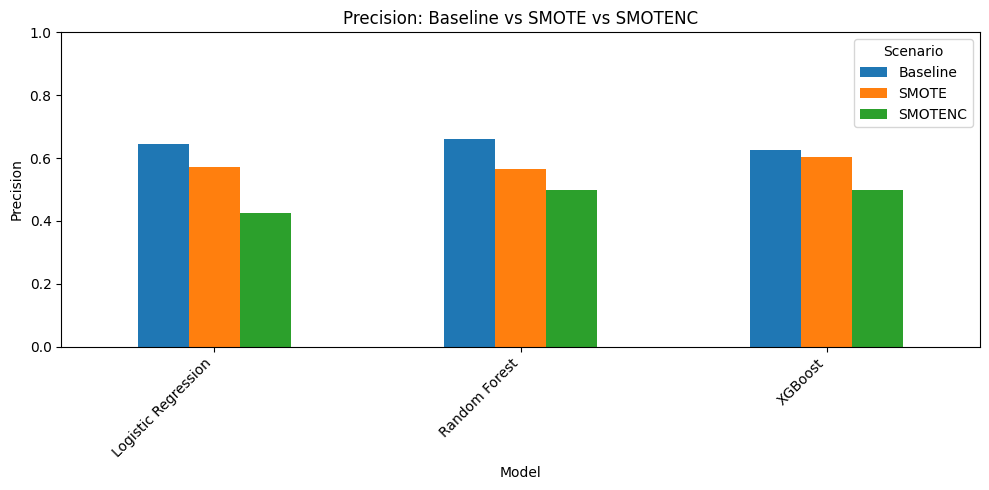

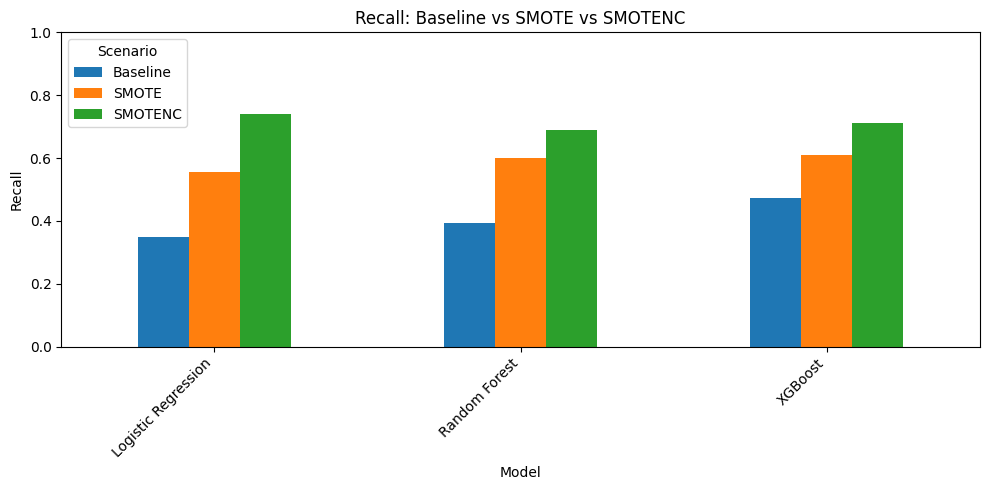

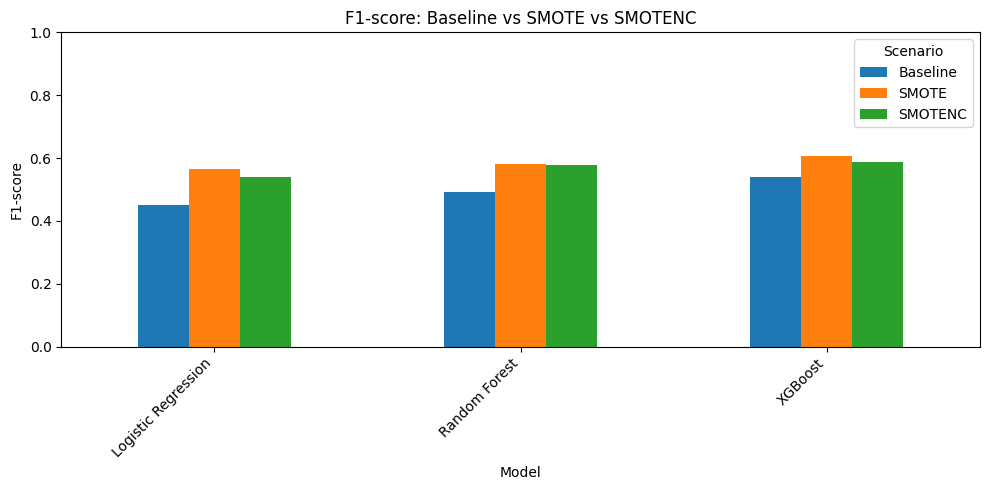

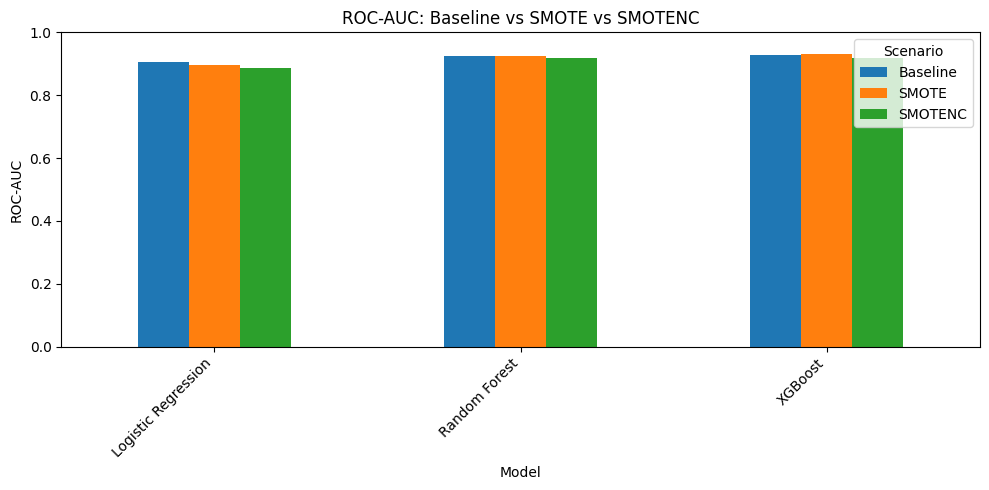

In [13]:
#Plotting the grouped bars
metrics = ["Precision", "Recall", "F1-score", "ROC-AUC"]

for metric in metrics:
    pivot_df = comparison_df.pivot(index="Model", columns="Scenario", values=metric)
    pivot_df.plot(kind="bar", figsize=(10, 5))
    plt.title(f"{metric}: Baseline vs SMOTE vs SMOTENC")
    plt.ylabel(metric)
    plt.ylim(0, 1)
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

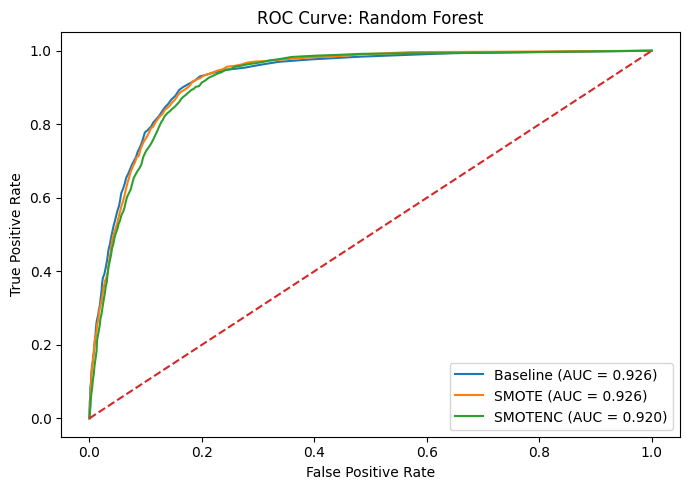

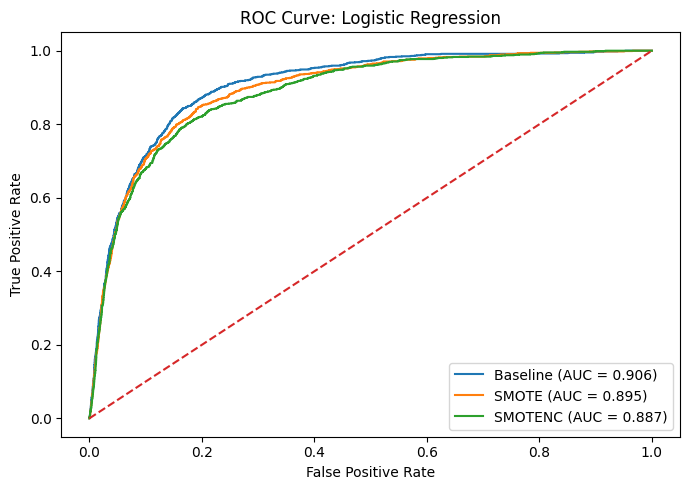

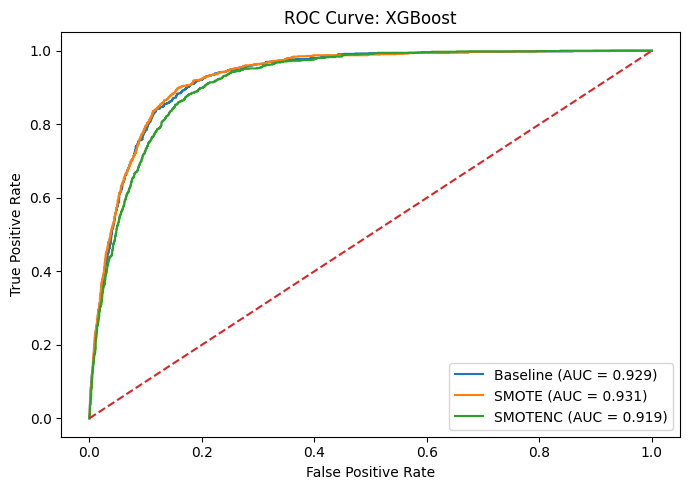

In [14]:
#Roc curves
def plot_roc_three_way(model_name, baseline_outputs, smote_outputs, smotenc_outputs, y_test):
    plt.figure(figsize=(7, 5))

    y_prob_base = baseline_outputs[model_name]["y_prob"]
    fpr_base, tpr_base, _ = roc_curve(y_test, y_prob_base)
    auc_base = roc_auc_score(y_test, y_prob_base)

    y_prob_smote = smote_outputs[model_name]["y_prob"]
    fpr_smote, tpr_smote, _ = roc_curve(y_test, y_prob_smote)
    auc_smote = roc_auc_score(y_test, y_prob_smote)

    y_prob_smotenc = smotenc_outputs[model_name]["y_prob"]
    fpr_smotenc, tpr_smotenc, _ = roc_curve(y_test, y_prob_smotenc)
    auc_smotenc = roc_auc_score(y_test, y_prob_smotenc)

    plt.plot(fpr_base, tpr_base, label=f"Baseline (AUC = {auc_base:.3f})")
    plt.plot(fpr_smote, tpr_smote, label=f"SMOTE (AUC = {auc_smote:.3f})")
    plt.plot(fpr_smotenc, tpr_smotenc, label=f"SMOTENC (AUC = {auc_smotenc:.3f})")
    plt.plot([0, 1], [0, 1], linestyle="--")

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve: {model_name}")
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_roc_three_way("Random Forest", baseline_outputs, smote_outputs, smotenc_outputs, y_test)
plot_roc_three_way("Logistic Regression", baseline_outputs, smote_outputs, smotenc_outputs, y_test)
plot_roc_three_way("XGBoost", baseline_outputs, smote_outputs, smotenc_outputs, y_test)

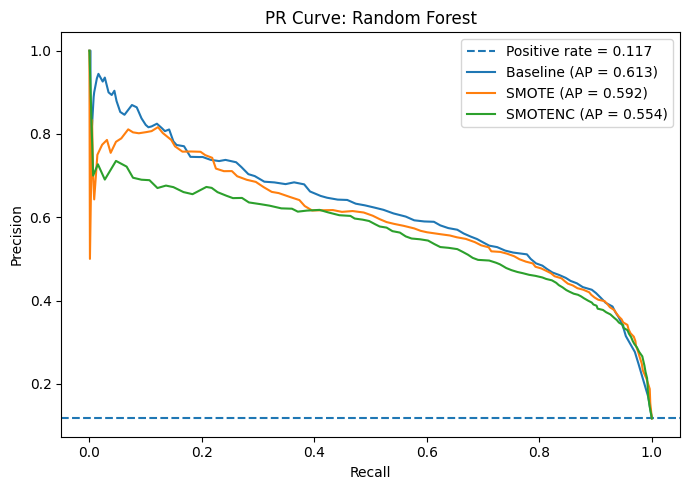

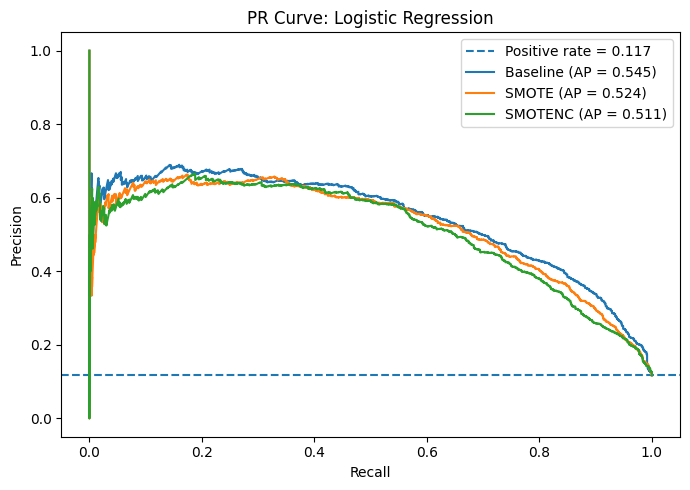

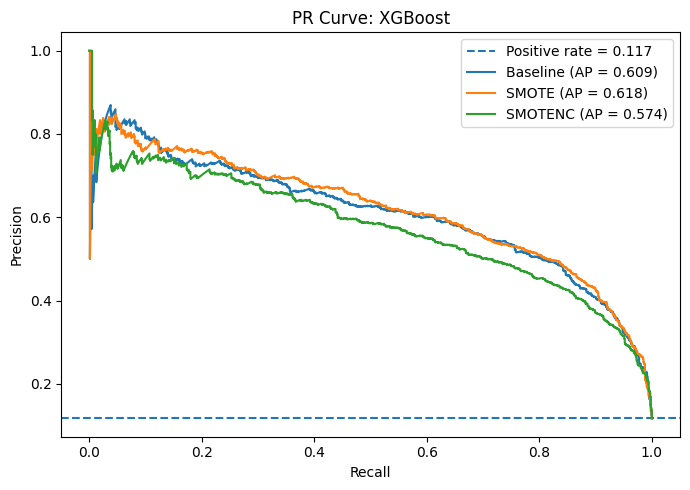

In [15]:
#PR curves
def plot_pr_three_way(model_name, baseline_outputs, smote_outputs, smotenc_outputs, y_test):
    plt.figure(figsize=(7, 5))

    positive_rate = y_test.mean()
    plt.axhline(y=positive_rate, linestyle="--", label=f"Positive rate = {positive_rate:.3f}")

    y_prob_base = baseline_outputs[model_name]["y_prob"]
    precision_base, recall_base, _ = precision_recall_curve(y_test, y_prob_base)
    ap_base = average_precision_score(y_test, y_prob_base)

    y_prob_smote = smote_outputs[model_name]["y_prob"]
    precision_smote, recall_smote, _ = precision_recall_curve(y_test, y_prob_smote)
    ap_smote = average_precision_score(y_test, y_prob_smote)

    y_prob_smotenc = smotenc_outputs[model_name]["y_prob"]
    precision_smotenc, recall_smotenc, _ = precision_recall_curve(y_test, y_prob_smotenc)
    ap_smotenc = average_precision_score(y_test, y_prob_smotenc)

    plt.plot(recall_base, precision_base, label=f"Baseline (AP = {ap_base:.3f})")
    plt.plot(recall_smote, precision_smote, label=f"SMOTE (AP = {ap_smote:.3f})")
    plt.plot(recall_smotenc, precision_smotenc, label=f"SMOTENC (AP = {ap_smotenc:.3f})")

    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"PR Curve: {model_name}")
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_pr_three_way("Random Forest", baseline_outputs, smote_outputs, smotenc_outputs, y_test)
plot_pr_three_way("Logistic Regression", baseline_outputs, smote_outputs, smotenc_outputs, y_test)
plot_pr_three_way("XGBoost", baseline_outputs, smote_outputs, smotenc_outputs, y_test)